<a href="https://colab.research.google.com/github/LailaDuffy/Python/blob/main/Torque_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Plot data from a CSV file.

## Load the data

### Subtask:
Load the data from a CSV file into a dataframe.


**Reasoning**:
The first step is to load the data from the CSV file into a pandas DataFrame and display the first few rows to understand its structure.



In [4]:
import pandas as pd

# Read the CSV file into a pandas DataFrame
df = pd.read_csv('/content/torque_data_LAB3-1751291627829.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Torque,timestamp
0,0.0,2025-06-26 12:27:58.177
1,0.0,2025-06-26 12:27:48.11
2,0.0,2025-06-26 12:27:38.029
3,0.0,2025-06-26 12:27:28.198
4,0.0,2025-06-26 09:42:49.817


## Prepare the data

### Subtask:
Clean and format the data for plotting.


**Reasoning**:
Inspect the DataFrame to identify suitable columns for plotting and check for missing values and data types.



In [5]:
display(df.info())
display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10690 entries, 0 to 10689
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Torque     10690 non-null  float64
 1   timestamp  10690 non-null  object 
dtypes: float64(1), object(1)
memory usage: 167.2+ KB


None

,Torque,timestamp
count,10690.000000,10690
unique,NaN,10690
top,NaN,2025-06-26 07:52:24.002
freq,NaN,1
mean,10.693837,NaN
std,360.508473,NaN
min,-2047.620000,NaN
25%,0.000000,NaN
50%,0.000000,NaN
75%,6.060000,NaN


**Reasoning**:
The previous attempt to convert 'timestamp' to datetime failed due to inconsistent formats. Using `errors='coerce'` will convert unparseable dates to NaT, allowing the conversion to proceed. Then, check for any remaining missing values.



In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
display(df.isnull().sum())

,0
Torque,0
timestamp,11


**Reasoning**:
Drop rows with missing values in the 'timestamp' column as they cannot be used for time-series plotting. Then, display the info of the dataframe to confirm the changes.



In [8]:
df.dropna(subset=['timestamp'], inplace=True)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 10679 entries, 0 to 10689
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Torque     10679 non-null  float64       
 1   timestamp  10679 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 250.3 KB


None

## Plot the data

### Subtask:
Create a plot using the prepared data.


**Reasoning**:
Create a line plot of 'Torque' against 'timestamp' using the prepared DataFrame `df` with appropriate labels and title.



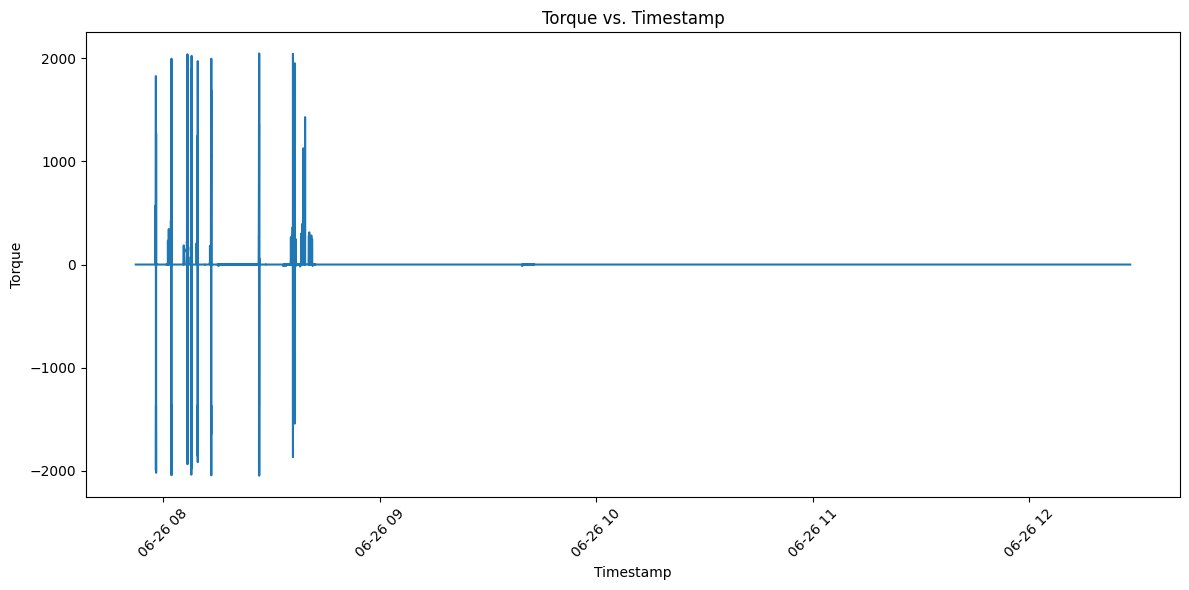

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['Torque'])
plt.xlabel('Timestamp')
plt.ylabel('Torque')
plt.title('Torque vs. Timestamp')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The initial attempt to load the data from `data.csv` failed due to a `FileNotFoundError`.
*   The 'timestamp' column was successfully converted to datetime objects, although 11 rows with invalid timestamps were dropped.
*   The 'Torque' column is of type float64 and contains no missing values.
*   A line plot of 'Torque' versus 'Timestamp' was successfully generated.

### Insights or Next Steps

*   Ensure the correct file path for `data.csv` is available for future analysis.
*   Consider investigating the cause of the invalid timestamp formats if they are expected to be valid.
